# Quantitative-DeFi-Research

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
class BlackScholes:
    """
    Implements Black-Scholes-Merton for European Options.
    """
    def __init__(self, S, K, T, r, sigma):
        self.S = S      # Spot Price
        self.K = K      # Strike Price
        self.T = T      # Time to Maturity (years)
        self.r = r      # Risk-free Rate
        self.sigma = sigma # Volatility
        
    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
    
    def d2(self):
        return self.d1() - self.sigma * np.sqrt(self.T)
    
    def call_price(self):
        return self.S * norm.cdf(self.d1()) - self.K * np.exp(-self.r * self.T) * norm.cdf(self.d2())
    
    def put_price(self):
        return self.K * np.exp(-self.r * self.T) * norm.cdf(-self.d2()) - self.S * norm.cdf(-self.d1())
    
    def call_delta(self):
        return norm.cdf(self.d1())

    def call_gamma(self):
        return norm.pdf(self.d1()) / (self.S * self.sigma * np.sqrt(self.T))

--- Option Pricing Model ---
ETH Spot: $2500 | Strike: $2600 | Vol: 60.0%
Theoretical Call Option Price: $133.35
Option Delta (Hedge Ratio): 0.4530


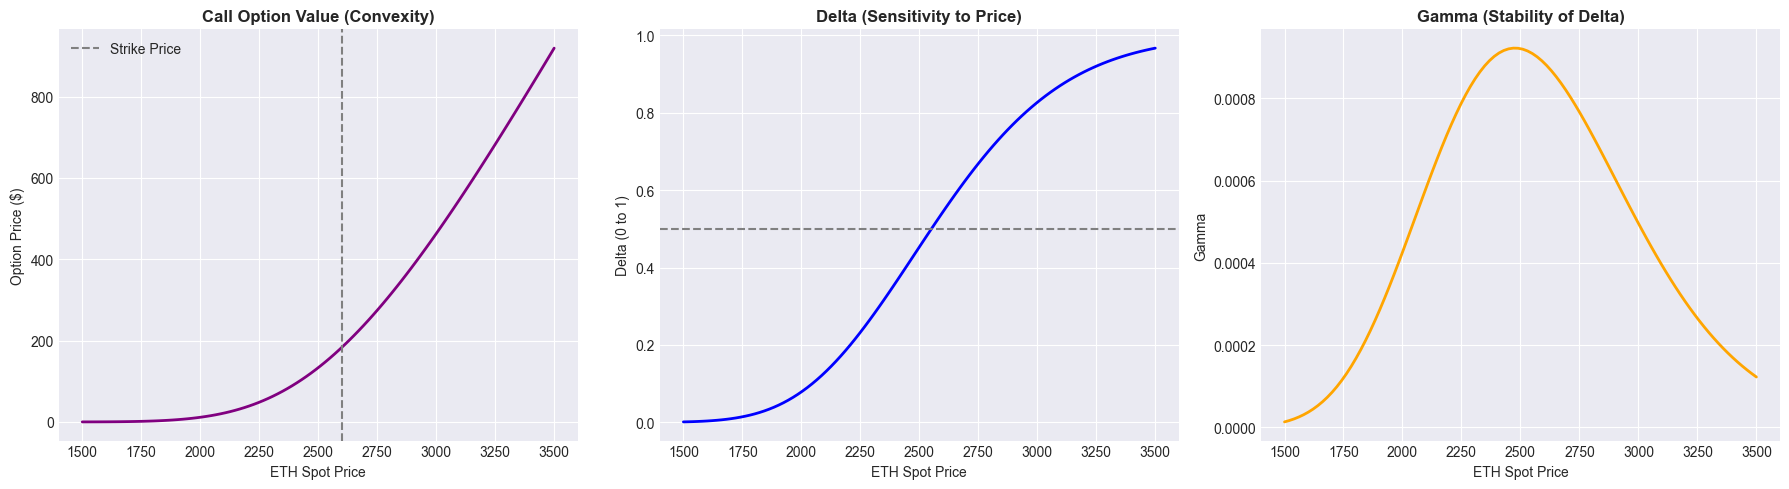

Option pricing charts generated.


In [4]:
if __name__ == "__main__":
    # Parameters for a hypothetical ETH Option
    S_current = 2500  # ETH Price
    K_strike = 2600   # Strike Price (Out of the Money)
    T_days = 30       # Days to expiry
    T_years = T_days / 365
    r_rate = 0.05     # Risk-free rate (5%)
    sigma_vol = 0.60  # 60% Annualized Volatility (Crypto is volatile!)
    
    model = BlackScholes(S_current, K_strike, T_years, r_rate, sigma_vol)
    price = model.call_price()
    delta = model.call_delta()
    
    print(f"--- Option Pricing Model ---")
    print(f"ETH Spot: ${S_current} | Strike: ${K_strike} | Vol: {sigma_vol*100}%")
    print(f"Theoretical Call Option Price: ${price:.2f}")
    print(f"Option Delta (Hedge Ratio): {delta:.4f}")
    
    # --- VISUALIZATION: THE GREEKS ---
    # Generate prices from $1500 to $3500 to see how option value changes
    spot_range = np.linspace(1500, 3500, 100)
    option_prices = []
    deltas = []
    gammas = []
    
    for s in spot_range:
        m = BlackScholes(s, K_strike, T_years, r_rate, sigma_vol)
        option_prices.append(m.call_price())
        deltas.append(m.call_delta())
        gammas.append(m.call_gamma())
        
    # Plot 1: Option Price vs Spot (Convexity)
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    ax[0].plot(spot_range, option_prices, color='purple', linewidth=2)
    ax[0].set_title('Call Option Value (Convexity)', fontweight='bold')
    ax[0].set_xlabel('ETH Spot Price')
    ax[0].set_ylabel('Option Price ($)')
    ax[0].axvline(K_strike, color='gray', linestyle='--', label='Strike Price')
    ax[0].legend()
    
    # Plot 2: Delta (Velocity)
    ax[1].plot(spot_range, deltas, color='blue', linewidth=2)
    ax[1].set_title('Delta (Sensitivity to Price)', fontweight='bold')
    ax[1].set_xlabel('ETH Spot Price')
    ax[1].set_ylabel('Delta (0 to 1)')
    ax[1].axhline(0.5, color='gray', linestyle='--')
    
    # Plot 3: Gamma (Acceleration)
    ax[2].plot(spot_range, gammas, color='orange', linewidth=2)
    ax[2].set_title('Gamma (Stability of Delta)', fontweight='bold')
    ax[2].set_xlabel('ETH Spot Price')
    ax[2].set_ylabel('Gamma')
    
    plt.tight_layout()
    plt.show()
    
    print("Option pricing charts generated.")